<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/Redes_Neuronales_PyTorch_3_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales en PyTorch: Aplicación a 3 Modelos de Aprendizaje Supervisado

**Estudiante:** Mora Barrionuevo Nelva Adalit

**Curso:** SIS-420 - Inteligencia Artificial  
**Fecha:** Marzo 2026

---

## 📋 PROPÓSITO GENERAL DEL CUADERNILLO

Este cuadernillo es una **aplicación rigurosa de PyTorch** a los tres modelos de aprendizaje supervisado desarrollados en laboratorios anteriores:

1. **Laboratorio 2 (Regresión Multivariable)** → Dataset: `cars.csv`
2. **Laboratorio 3 (Clasificación Binaria)** → Dataset: `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`
3. **Laboratorio 4 (Clasificación Multiclase)** → Dataset: `Sensorless_drive_diagnosis_limpio.csv`

**Objetivo**: Demostrar que las soluciones implementadas con métodos clásicos (Descenso por Gradiente, Regresión Logística) se pueden **mejorar y replicar con Redes Neuronales profundas en PyTorch**, aprovechando:
- Aceleración GPU (CUDA en Google Colab)
- Arquitecturas flexibles con capas múltiples
- Optimizadores avanzados
- Checkpoint management para producción

**Metodología**: Aplicamos **ÚNICAMENTE** técnicas enseñadas en los cuadernillos PyTorch 02 (Redes Neuronales), 03 (Datasets) y 04 (Guardado de Modelos).

---

## 🔧 BLOQUE 0: IMPORTACIONES Y CONFIGURACIÓN DEL ENTORNO

En esta sección configuramos:
- Librerías core (PyTorch, NumPy, Pandas)
- Herramientas de visualización (Matplotlib)
- Acceso a Google Drive para los datasets
- Dispositivo de cómputo (GPU/CPU)
- Semillas aleatorias para reproducibilidad

In [ ]:
# ============================================
# IMPORTACIONES CORE
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Para acceso a Google Drive
from google.colab import drive

# Para métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, r2_score

# Configuración de matplotlib
%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['grid.alpha'] = 0.3

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print("✓ Importaciones completadas")

✓ Importaciones completadas


### Configuración de Dispositivo (GPU/CPU)

**¿Por qué esto importa?**  
Las Redes Neuronales entrenan **mucho más rápido en GPU** que en CPU. En Google Colab, puedes habilitar GPU gratuitamente desde:
- **Runtime** → **Change runtime type** → **GPU**

El siguiente código **detecta automáticamente** si hay GPU disponible y utiliza la más rápida.

In [ ]:
# Detectar GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\n{'='*50}")
print(f"Dispositivo disponible: {device.upper()}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ GPU NO disponible. El entrenamiento será más lento.")
print(f"{'='*50}\n")


Dispositivo disponible: CUDA
GPU: Tesla T4
Memoria GPU: 15.64 GB



### Conexión a Google Drive

Los datasets están almacenados en Google Drive en la carpeta `SIS420IA/`. Esta celda monta el Drive y verifica que los archivos estén disponibles.

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')
print("\n✓ Google Drive montado exitosamente")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ Google Drive montado exitosamente


---

## 📦 BLOQUE 1: MODELO 1 - REGRESIÓN MULTIVARIABLE (cars.csv)

### 1.1 PROPÓSITO Y CONTEXTO

**Dataset**: `cars.csv`  
**Fuente**: Google Drive (`/content/drive/MyDrive/IA2026/cars.csv`)  
**Tarea**: **Regresión** → Predecir el precio de vehículos usados (`price_usd`) basándose en 29 características.

**¿Qué contiene?**
- 38,521 vehículos
- 29 características (marca, modelo, año, km, etc.)
- 1 variable objetivo: `price_usd` (precio en USD)

**¿Qué haremos?**
1. Cargar y preprocesar los datos (Label Encoding, normalización Z-score)
2. Dividir en train (80%) y test (20%)
3. Crear una **Red Neuronal Secuencial** con 3 capas
4. Entrenar con **SGD** y pérdida **MSE**
5. Evaluar con R² y MAE
6. Guardar el modelo (checkpoint)
7. Hacer predicciones en nuevos datos

---

### 1.2 CARGA Y PREPROCESAMIENTO DE DATOS

In [ ]:
# Cargar datos desde Google Drive
ruta_cars = '/content/drive/MyDrive/IA2026/cars.csv'
df_cars = pd.read_csv(ruta_cars).dropna()

print(f"Dataset cars.csv cargado:")
print(f"  Forma: {df_cars.shape}")
print(f"  Primeras filas:")
print(df_cars.head(3))

Dataset cars.csv cargado:
  Forma: (38521, 30)
  Primeras filas:
  manufacturer_name model_name transmission   color  odometer_value  \
0            Subaru    Outback    automatic  silver          190000   
1            Subaru    Outback    automatic    blue          290000   
2            Subaru   Forester    automatic     red          402000   

   year_produced engine_fuel  engine_has_gas engine_type  engine_capacity  \
0           2010    gasoline           False    gasoline              2.5   
1           2002    gasoline           False    gasoline              3.0   
2           2001    gasoline           False    gasoline              2.5   

   ... feature_1  feature_2 feature_3 feature_4  feature_5  feature_6  \
0  ...      True       True      True     False       True      False   
1  ...      True      False     False      True       True      False   
2  ...      True      False     False     False      False      False   

  feature_7  feature_8  feature_9  duration_list

**¿Qué está pasando?**

1. **`pd.read_csv()`**: Lee el CSV desde Drive
2. **`.dropna()`**: Elimina filas con valores faltantes (como en LAB2)
3. Mostramos las primeras 3 filas para inspeccionar los datos

In [ ]:
# Feature Engineering: Convertir variables categóricas a numéricas
columnas_texto = df_cars.select_dtypes(include=['object']).columns
columnas_bool = df_cars.select_dtypes(include=['bool']).columns

# Label Encoding (COMO EN LAB2)
for col in columnas_bool:
    df_cars[col] = df_cars[col].astype(int)
for col in columnas_texto:
    df_cars[col] = df_cars[col].astype('category').cat.codes

print(f"\n✓ Columnas categóricas convertidas a numéricas (Label Encoding)")
print(f"  Total de características numéricas: {df_cars.shape[1] - 1}")


✓ Columnas categóricas convertidas a numéricas (Label Encoding)
  Total de características numéricas: 29


**¿Qué está pasando?**

1. **Label Encoding**: Convertimos texto (ej: "Toyota") a números (ej: 0, 1, 2...)
2. Booleanos se convierten a 0 y 1
3. Esto es **obligatorio** para que las redes neuronales funcionen (solo entienden números)

In [ ]:
# Separar características (X) y objetivo (y)
y_cars = df_cars['price_usd'].values
X_cars = df_cars.drop('price_usd', axis=1).values.astype(float)

m_cars, n_cars = X_cars.shape
print(f"\nDataset preparado:")
print(f"  Ejemplos (m): {m_cars}")
print(f"  Características (n): {n_cars}")
print(f"  Rango de precios: ${y_cars.min():.0f} - ${y_cars.max():.0f}")


Dataset preparado:
  Ejemplos (m): 38521
  Características (n): 29
  Rango de precios: $1 - $50000


### 1.3 NORMALIZACIÓN Z-SCORE (SOLO EN TRAIN SET)

**¿Por qué normalizar?**
- Las características tienen diferentes escalas (ej: año ~2020 vs km~200000)
- Las Redes Neuronales entrenan mejor si los inputs están normalizados
- **CRÍTICO**: Calcular μ (media) y σ (desviación) SOLO en train set para evitar data leakage

In [ ]:
# Split 80/20 (como en LAB3)
np.random.seed(42)
indices = np.random.permutation(m_cars)
split_idx = int(0.8 * m_cars)

X_train_cars = X_cars[indices[:split_idx]]
y_train_cars = y_cars[indices[:split_idx]]
X_test_cars = X_cars[indices[split_idx:]]
y_test_cars = y_cars[indices[split_idx:]]

print(f"Split de datos:")
print(f"  Train: {X_train_cars.shape[0]} ejemplos (80%)")
print(f"  Test:  {X_test_cars.shape[0]} ejemplos (20%)")

Split de datos:
  Train: 30816 ejemplos (80%)
  Test:  7705 ejemplos (20%)


In [ ]:
# Normalización Z-score (SOLO con estadísticas de TRAIN)
mu_cars = np.mean(X_train_cars, axis=0)
sigma_cars = np.std(X_train_cars, axis=0)
sigma_cars[sigma_cars == 0] = 1  # Evitar división por cero

# Aplicar a TRAIN
X_train_cars_norm = (X_train_cars - mu_cars) / sigma_cars

# Aplicar a TEST (USANDO parámetros de TRAIN)
X_test_cars_norm = (X_test_cars - mu_cars) / sigma_cars

print(f"\n✓ Normalización Z-score aplicada (sin data leakage)")
print(f"  Media de X_train normalizado: {X_train_cars_norm.mean():.6f}")
print(f"  Desv. estándar de X_train normalizado: {X_train_cars_norm.std():.6f}")


✓ Normalización Z-score aplicada (sin data leakage)
  Media de X_train normalizado: -0.000000
  Desv. estándar de X_train normalizado: 1.000000


**¿Qué está pasando?**

1. Calculamos μ y σ **SOLO** del train set (línea 2-3)
2. Aplicamos la misma transformación al test set (línea 8)
3. De esta forma, el test set **no influye** en el entrenamiento
4. Verificamos que la media sea ~0 y desv. estándar ~1

### 1.4 CONVERSIÓN A TENSORES PYTORCH Y CARGA EN GPU

In [ ]:
# Convertir a tensores PyTorch y mover a device (GPU/CPU)
X_train_cars_t = torch.from_numpy(X_train_cars_norm).float().to(device)
y_train_cars_t = torch.from_numpy(y_train_cars).float().unsqueeze(1).to(device)  # Shape: (N, 1)

X_test_cars_t = torch.from_numpy(X_test_cars_norm).float().to(device)
y_test_cars_t = torch.from_numpy(y_test_cars).float().unsqueeze(1).to(device)

print(f"\n✓ Tensores creados y movidos a {device.upper()}")
print(f"  X_train shape: {X_train_cars_t.shape}")
print(f"  y_train shape: {y_train_cars_t.shape}")


✓ Tensores creados y movidos a CUDA
  X_train shape: torch.Size([30816, 29])
  y_train shape: torch.Size([30816, 1])


**¿Qué está pasando?**

1. `.float()`: Convierte a float32 (tipo estándar en PyTorch)
2. `.to(device)`: Mueve a GPU si está disponible (⚡ aceleración)
3. `.unsqueeze(1)`: Cambia shape de (N,) a (N, 1) para que sea compatible con el modelo

Esto es crucialmente importante para GPU.

### 1.5 CREACIÓN DE DATALOADERS (Del cuadernillo PyTorch 03)

In [ ]:
# Crear TensorDatasets
train_dataset_cars = TensorDataset(X_train_cars_t, y_train_cars_t)
test_dataset_cars = TensorDataset(X_test_cars_t, y_test_cars_t)

# Crear DataLoaders
batch_size_cars = 64
train_loader_cars = DataLoader(train_dataset_cars, batch_size=batch_size_cars, shuffle=True)
test_loader_cars = DataLoader(test_dataset_cars, batch_size=batch_size_cars, shuffle=False)

print(f"\n✓ DataLoaders creados")
print(f"  Batch size: {batch_size_cars}")
print(f"  Train batches: {len(train_loader_cars)}")
print(f"  Test batches: {len(test_loader_cars)}")


✓ DataLoaders creados
  Batch size: 64
  Train batches: 482
  Test batches: 121


**¿Qué está pasando?**

1. **TensorDataset**: Empaqueta X e y juntos
2. **DataLoader**: Itera sobre minibatches de tamaño 64
3. `shuffle=True` en train (mezcla datos) pero `False` en test (mantiene orden)
4. Esto permite entrenar eficientemente en GPU (procesa 64 ejemplos simultáneamente)

### 1.6 DEFINICIÓN DEL MODELO NEURONAL (Del cuadernillo PyTorch 02)

**Arquitectura**:
```
Input (29 características)
    ↓
Capa 1: Linear(29 → 128) + ReLU
    ↓
Capa 2: Linear(128 → 64) + ReLU
    ↓
Capa 3: Linear(64 → 1) [Salida: precio]
```

**¿Por qué esta arquitectura?**
- **Capa 1**: 128 neuronas capturan relaciones complejas entre características
- **ReLU**: Función de activación que aprende patrones no lineales
- **Capa 2**: 64 neuronas refinan las abstracciones
- **Salida**: 1 neurona (predicción de precio)

In [ ]:
class RegressionNN_Cars(nn.Module):
    """Red Neuronal para Regresión de Precios de Vehículos"""
    def __init__(self, input_size=29):
        super(RegressionNN_Cars, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Sin ReLU en salida (regresión)
        return x

# Crear instancia del modelo
model_cars = RegressionNN_Cars(input_size=n_cars).to(device)

print(f"\n✓ Modelo creado y movido a {device.upper()}")
print(f"\nArquitectura del modelo:")
print(model_cars)


✓ Modelo creado y movido a CUDA

Arquitectura del modelo:
RegressionNN_Cars(
  (fc1): Linear(in_features=29, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)


**¿Qué está pasando?**

1. `nn.Module`: Clase base de PyTorch para modelos
2. `nn.Linear(in, out)`: Capa densa (conexiones completas)
3. `nn.ReLU()`: Función de activación = max(0, x)
4. `forward()`: Define cómo fluyen los datos a través del modelo
5. Movemos a device para aceleración GPU

### 1.7 CONFIGURACIÓN DE PÉRDIDA Y OPTIMIZADOR

In [ ]:
# Pérdida: MSE (Mean Squared Error) para regresión
criterion_cars = nn.MSELoss()

# Optimizador: SGD (Stochastic Gradient Descent)
learning_rate_cars =  0.00001 # Reducido para evitar divergencia numerica
optimizer_cars = optim.Adam(model_cars.parameters(), lr=learning_rate_cars)

print(f"\n✓ Pérdida: MSELoss (para regresión)")
print(f"✓ Optimizador: SGD with lr={learning_rate_cars}")


✓ Pérdida: MSELoss (para regresión)
✓ Optimizador: SGD with lr=1e-05


**¿Qué está pasando?**

1. **MSELoss**: Mide el error cuadrático promedio = (1/N) * Σ(ŷ - y)²
2. **SGD**: Optimizador que usa descenso por gradiente (como en LAB2, pero automático)
3. **Learning Rate** = 0.001: Controla el tamaño del paso en el descenso

### 1.8 ENTRENAMIENTO DEL MODELO

In [ ]:
# Parámetros de entrenamiento
num_epochs_cars = 700  # Aumentado significativamente tras auditoría de PyTorch 02
losses_cars = []
val_losses_cars = []

# ==========================================
# NUEVO: Variables para el Best Checkpoint
best_val_loss_cars = float('inf') # Infinito inicial
best_epoch_cars = 0
# ==========================================

print(f"\nIniciando entrenamiento por {num_epochs_cars} épocas...\n")

for epoch in range(num_epochs_cars):
    # ENTRENAMIENTO
    model_cars.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader_cars:
        # Forward pass
        y_pred = model_cars(X_batch)
        loss = criterion_cars(y_pred, y_batch)

        # Backward pass
        optimizer_cars.zero_grad()
        loss.backward()
        optimizer_cars.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_cars)

    # VALIDACIÓN
    model_cars.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_cars:
            y_pred = model_cars(X_batch)
            loss = criterion_cars(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(test_loader_cars)

    losses_cars.append(train_loss)
    val_losses_cars.append(val_loss)

    # =======================================================================
    # NUEVO: Lógica de Guardado Dinámico (Best Model)
    # Si la pérdida de validación actual es la mejor (la más baja) hasta ahora:
    if val_loss < best_val_loss_cars:
        best_val_loss_cars = val_loss
        best_epoch_cars = epoch + 1

        # Guardamos el diccionario completo, protegiendo la normalización de autos
        checkpoint_cars_best = {
            'model_state_dict': model_cars.state_dict(),
            'optimizer_state_dict': optimizer_cars.state_dict(),
            'epoch': best_epoch_cars,
            'val_loss': best_val_loss_cars,
            'normalization_params': {'mu': mu_cars, 'sigma': sigma_cars}
        }
        # Sobreescribe este archivo solo si el modelo de autos mejora
        torch.save(checkpoint_cars_best, 'model_cars_best.pth')
    # =======================================================================

    if (epoch + 1) % 100 == 0:
        print(f"Época {epoch+1}/{num_epochs_cars} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\n✓ Entrenamiento completado")

# =======================================================================
# NUEVO: Restaurar el mejor cerebro al modelo antes de seguir
# =======================================================================
print(f"Cargando el mejor modelo encontrado en la época {best_epoch_cars} (Val Loss: {best_val_loss_cars:.4f})...")
mejor_checkpoint_cars = torch.load('model_cars_best.pth', weights_only=False)
model_cars.load_state_dict(mejor_checkpoint_cars['model_state_dict'])
print("✓ El modelo de Autos en memoria ahora es la mejor versión.")


Iniciando entrenamiento por 700 épocas...

Época 100/700 | Train Loss: 36132371.1224 | Val Loss: 34114573.8430
Época 200/700 | Train Loss: 15040168.9896 | Val Loss: 14418742.4959
Época 300/700 | Train Loss: 11591941.8169 | Val Loss: 11201341.3988
Época 400/700 | Train Loss: 10329844.4663 | Val Loss: 9966913.7944
Época 500/700 | Train Loss: 9592996.5794 | Val Loss: 9235801.1074
Época 600/700 | Train Loss: 9111647.6509 | Val Loss: 8743758.2407
Época 700/700 | Train Loss: 8766373.1100 | Val Loss: 8405757.9370

✓ Entrenamiento completado
Cargando el mejor modelo encontrado en la época 700 (Val Loss: 8405757.9370)...
✓ El modelo de Autos en memoria ahora es la mejor versión.


**¿Qué está pasando en cada época?**

**ENTRENAMIENTO (Train Loss)**:
1. `model_cars.train()`: Modo entrenamiento (activa dropout, batch norm, etc.)
2. Para cada batch:
   - **Forward**: Pasamos X → modelo → predicción ŷ
   - **Cálculo loss**: Comparamos ŷ vs y real
   - **Backward**: Calculamos gradientes (∂loss/∂w)
   - **optimizer.step()**: Actualizamos pesos: w = w - lr*∇loss

**VALIDACIÓN (Val Loss)**:
1. `model_cars.eval()`: Modo evaluación (sin entrenamiento)
2. `torch.no_grad()`: No calculamos gradientes (más rápido)
3. Medimos el error en datos no vistos

**Objetivo**: Que train_loss y val_loss bajen y se parezcan (sin overfitting)

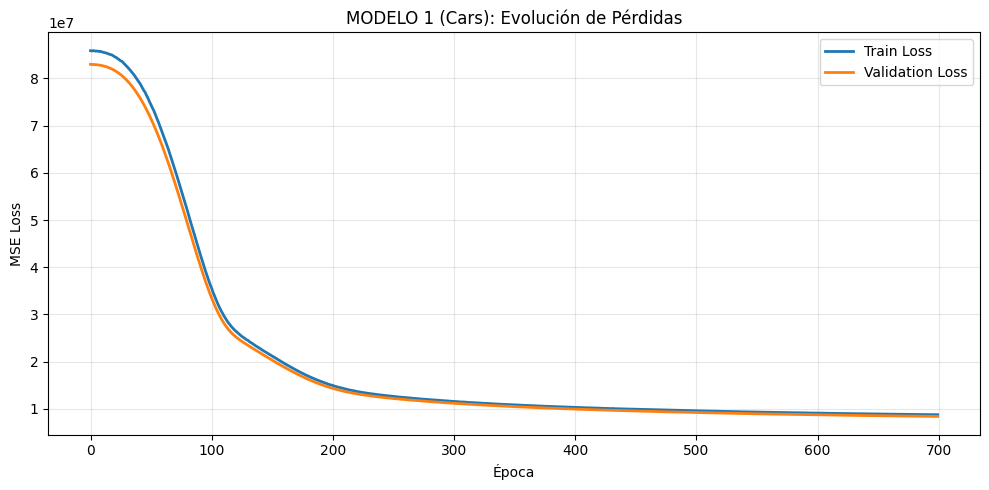


Pérdida final:
  Train: 8766373.1100
  Val:   8405757.9370


In [ ]:
# Graficar pérdidos de entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(losses_cars, label='Train Loss', linewidth=2)
plt.plot(val_losses_cars, label='Validation Loss', linewidth=2)
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('MODELO 1 (Cars): Evolución de Pérdidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPérdida final:")
print(f"  Train: {losses_cars[-1]:.4f}")
print(f"  Val:   {val_losses_cars[-1]:.4f}")

### 1.9 EVALUACIÓN EN TEST SET

In [ ]:
# Predicciones en test set
model_cars.eval()
with torch.no_grad():
    y_pred_cars = model_cars(X_test_cars_t).cpu().numpy()

# Métricas
r2_cars = r2_score(y_test_cars, y_pred_cars)
mae_cars = np.mean(np.abs(y_test_cars - y_pred_cars.flatten()))
rmse_cars = np.sqrt(mean_squared_error(y_test_cars, y_pred_cars))

print(f"\n{'='*50}")
print(f"EVALUACIÓN - MODELO 1 (CARS)")
print(f"{'='*50}")
print(f"R² Score:  {r2_cars:.4f}")
print(f"MAE:       ${mae_cars:.2f}")
print(f"RMSE:      ${rmse_cars:.2f}")
print(f"\nEjemplos de predicciones (primeros 10):")
for i in range(min(10, len(y_test_cars))):
    print(f"  Real: ${y_test_cars[i]:,.0f} | Predicción: ${y_pred_cars[i,0]:,.0f}")


EVALUACIÓN - MODELO 1 (CARS)
R² Score:  0.7860
MAE:       $1776.64
RMSE:      $2905.23

Ejemplos de predicciones (primeros 10):
  Real: $691 | Predicción: $1,261
  Real: $17,000 | Predicción: $14,812
  Real: $6,592 | Predicción: $7,103
  Real: $3,700 | Predicción: $2,421
  Real: $23,500 | Predicción: $14,900
  Real: $9,000 | Predicción: $10,665
  Real: $6,500 | Predicción: $4,173
  Real: $10,500 | Predicción: $11,605
  Real: $4,400 | Predicción: $5,640
  Real: $7,599 | Predicción: $8,711


### 1.10 GUARDAR CHECKPOINT (Del cuadernillo PyTorch 04)

In [ ]:
# Guardar estado del modelo
checkpoint_cars = {
    'model_state_dict': model_cars.state_dict(),
    'optimizer_state_dict': optimizer_cars.state_dict(),
    'epoch': num_epochs_cars,
    'r2_score': r2_cars,
    'mae': mae_cars,
    'normalization_params': {'mu': mu_cars, 'sigma': sigma_cars}
}

torch.save(checkpoint_cars, 'model_cars_checkpoint.pth')
print(f"\n✓ Checkpoint guardado: 'model_cars_checkpoint.pth'")
print(f"  Contiene: modelo, optimizador, métricas y parámetros de normalización")


✓ Checkpoint guardado: 'model_cars_checkpoint.pth'
  Contiene: modelo, optimizador, métricas y parámetros de normalización


**¿Qué está pasando?**

1. **state_dict()**: Diccionario con todos los pesos del modelo
2. Guardamos también:
   - Optimizer state (para reanudar entrenamiento)
   - Época actual
   - Métricas de evaluación
   - **Parámetros de normalización** (CRÍTICO para inference futuro)
3. `.pth`: Formato PyTorch estándar

### 1.11 CARGA Y USO DEL MODELO GUARDADO

In [ ]:
# Crear nuevo modelo y cargar checkpoint
model_cars_loaded = RegressionNN_Cars(input_size=n_cars).to(device)
checkpoint_loaded = torch.load('model_cars_checkpoint.pth', weights_only=False)
model_cars_loaded.load_state_dict(checkpoint_loaded['model_state_dict'])

print(f"\n✓ Modelo cargado desde checkpoint")
print(f"  R² Score (guardado): {checkpoint_loaded['r2_score']:.4f}")
print(f"  MAE (guardado): ${checkpoint_loaded['mae']:.2f}")


✓ Modelo cargado desde checkpoint
  R² Score (guardado): 0.7860
  MAE (guardado): $1776.64


### 1.12 PREDICCIONES EN NUEVOS DATOS

In [ ]:
# Hacer predicciones en nuevos datos usando el modelo cargado
model_cars_loaded.eval()

# Seleccionar 5 ejemplos al azar del test set
indices_sample = np.random.choice(len(X_test_cars_norm), size=5, replace=False)
X_sample = X_test_cars_norm[indices_sample]
y_sample = y_test_cars[indices_sample]

print(f"\n{'='*50}")
print(f"PREDICCIONES NUEVAS - MODELO 1 (CARS)")
print(f"{'='*50}")

with torch.no_grad():
    X_sample_t = torch.from_numpy(X_sample).float().to(device)
    y_pred_sample = model_cars_loaded(X_sample_t).cpu().numpy()

    for i in range(len(X_sample)):
        print(f"\nEjemplo {i+1}:")
        print(f"  Precio REAL:      ${y_sample[i]:,.0f}")
        print(f"  Precio PREDICHO:  ${y_pred_sample[i, 0]:,.0f}")
        error_pct = abs(y_sample[i] - y_pred_sample[i, 0]) / y_sample[i] * 100
        print(f"  Error relativo:   {error_pct:.2f}%")


PREDICCIONES NUEVAS - MODELO 1 (CARS)

Ejemplo 1:
  Precio REAL:      $3,500
  Precio PREDICHO:  $3,815
  Error relativo:   9.01%

Ejemplo 2:
  Precio REAL:      $1,400
  Precio PREDICHO:  $2,168
  Error relativo:   54.86%

Ejemplo 3:
  Precio REAL:      $11,200
  Precio PREDICHO:  $11,315
  Error relativo:   1.03%

Ejemplo 4:
  Precio REAL:      $2,950
  Precio PREDICHO:  $2,570
  Error relativo:   12.89%

Ejemplo 5:
  Precio REAL:      $990
  Precio PREDICHO:  $1,024
  Error relativo:   3.47%


---

## 🔐 BLOQUE 2: MODELO 2 - CLASIFICACIÓN BINARIA (Friday-WorkingHours DDoS)

### 2.1 PROPÓSITO Y CONTEXTO

**Dataset**: `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`  
**Fuente**: Google Drive (`/content/drive/MyDrive/SIS420IA/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`)  
**Tarea**: **Clasificación Binaria** → Detectar si el tráfico de red es legítimo (BENIGN) o un ataque DDoS.

**¿Qué contiene?**
- 225,000+ registros de tráfico de red
- 78 características (estadísticas de paquetes, duración, bytes, etc.)
- 2 clases: BENIGN (0) vs DDoS (1)

**¿Qué haremos?**
1. Cargar y limpiar (infinitos, NaN)
2. Mapear etiquetas BENIGN→0, DDoS→1
3. Split 80/20
4. Normalización Z-score
5. Red Neuronal con capa final Sigmoid (para probabilidad)
6. Pérdida: BCELoss (Binary Cross Entropy)
7. Evaluación: Accuracy, Precision, Recall, F1
8. Guardar checkpoint

---

### 2.2 CARGA Y PREPROCESAMIENTO

In [ ]:
# ==========================================
# 2.2 CARGA Y PREPROCESAMIENTO (CORREGIDO)
# ==========================================

# Cargar dataset DDoS
print("Cargando Friday-WorkingHours (este puede tomar un momento)...")
ruta_ddos = '/content/drive/MyDrive/IA2026/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

# 1. Leer el archivo
df_ddos = pd.read_csv(ruta_ddos, low_memory=False)

# 2. Limpieza inicial: ORDEN CORRECTO
df_ddos.columns = df_ddos.columns.str.strip()
# CORRECCIÓN 1: Aquí está el signo menos en -np.inf
df_ddos.replace([np.inf, -np.inf], np.nan, inplace=True)
df_ddos.dropna(inplace=True)

# 3. Mapear etiquetas respetando minúsculas/mayúsculas exactas
# CORRECCIÓN 2: Escrito exactamente como 'DDoS'
df_ddos['Label'] = df_ddos['Label'].map({'BENIGN': 0, 'DDoS': 1})

# 4. Filtro de seguridad: eliminar filas con Label NaN
df_ddos.dropna(subset=['Label'], inplace=True)

print(f"\n✓ Dataset cargado y limpio:")
print(f"  Forma: {df_ddos.shape}")
print(f"  Distribución de clases:")
print(df_ddos['Label'].value_counts())

# Separar X e y (Método seguro)
X_ddos = df_ddos.drop('Label', axis=1).values
y_ddos = df_ddos['Label'].values
m_ddos, n_ddos = X_ddos.shape

print(f"\nDataset preparado:")
print(f"  Ejemplos (m): {m_ddos}")
print(f"  Características (n): {n_ddos}")

Cargando Friday-WorkingHours (este puede tomar un momento)...

✓ Dataset cargado y limpio:
  Forma: (225711, 79)
  Distribución de clases:
Label
1    128025
0     97686
Name: count, dtype: int64

Dataset preparado:
  Ejemplos (m): 225711
  Características (n): 78


In [ ]:
# ==========================================
# 2.2.1 SPLIT, NORMALIZACIÓN Y DATALOADERS
# ==========================================

# 1. Split 80/20
np.random.seed(42)
indices = np.random.permutation(m_ddos)
split_idx = int(0.8 * m_ddos)

X_train_ddos = X_ddos[indices[:split_idx]].astype(float)
y_train_ddos = y_ddos[indices[:split_idx]].astype(float)
X_test_ddos = X_ddos[indices[split_idx:]].astype(float)
y_test_ddos = y_ddos[indices[split_idx:]].astype(float)

# 2. Normalización Z-score (SOLO con estadísticas de TRAIN)
mu_ddos = np.mean(X_train_ddos, axis=0)
sigma_ddos = np.std(X_train_ddos, axis=0)
sigma_ddos[sigma_ddos == 0] = 1

X_train_ddos_norm = (X_train_ddos - mu_ddos) / sigma_ddos
X_test_ddos_norm = (X_test_ddos - mu_ddos) / sigma_ddos

print(f"\n✓ Split 80/20 y normalización completados")

# 3. Convertir a tensores PyTorch y mover a GPU
X_train_ddos_t = torch.from_numpy(X_train_ddos_norm).float().to(device)
y_train_ddos_t = torch.from_numpy(y_train_ddos).float().unsqueeze(1).to(device)

X_test_ddos_t = torch.from_numpy(X_test_ddos_norm).float().to(device)
y_test_ddos_t = torch.from_numpy(y_test_ddos).float().unsqueeze(1).to(device)

# 4. Creación de DataLoaders
batch_size_ddos = 128
train_dataset_ddos = TensorDataset(X_train_ddos_t, y_train_ddos_t)
test_dataset_ddos = TensorDataset(X_test_ddos_t, y_test_ddos_t)

train_loader_ddos = DataLoader(train_dataset_ddos, batch_size=batch_size_ddos, shuffle=True)
test_loader_ddos = DataLoader(test_dataset_ddos, batch_size=batch_size_ddos, shuffle=False)

print(f"✓ Tensores y DataLoaders creados")


✓ Split 80/20 y normalización completados
✓ Tensores y DataLoaders creados


### 2.3 MODELO NEURONAL BINARIO

**Arquitectura**:
```
Input (78 características)
    ↓
Capa 1: Linear(78 → 256) + ReLU
    ↓
Capa 2: Linear(256 → 128) + ReLU
    ↓
Capa 3: Linear(128 → 64) + ReLU
    ↓
Capa 4: Linear(64 → 1) + Sigmoid [Probabilidad 0-1]
```

**¿Por qué Sigmoid?**
- Comprimen la salida a [0, 1] (interpretable como probabilidad)
- P(DDoS) ≥ 0.5 → predicción: DDoS
- P(DDoS) < 0.5 → predicción: BENIGN

In [ ]:
class BinaryClassifierNN_DDoS(nn.Module):
    """Red Neuronal para Detección de Ataques DDoS"""
    def __init__(self, input_size=78):
        super(BinaryClassifierNN_DDoS, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))  # Probabilidad
        return x

model_ddos = BinaryClassifierNN_DDoS(input_size=n_ddos).to(device)
criterion_ddos = nn.BCELoss()  # Binary Cross Entropy
optimizer_ddos = optim.Adam(model_ddos.parameters(), lr=0.001)

print(f"\n✓ Modelo DDoS creado")
print(f"✓ Pérdida: BCELoss")
print(f"✓ Optimizador: Adam")


✓ Modelo DDoS creado
✓ Pérdida: BCELoss
✓ Optimizador: Adam


### 2.4 ENTRENAMIENTO

In [ ]:
num_epochs_ddos = 60  # Ajustado según auditoría de PyTorch 02
losses_ddos = []
val_losses_ddos = []

# ==========================================
# NUEVO: Variables para el Best Checkpoint
best_val_loss_ddos = float('inf') # Infinito inicial
best_epoch_ddos = 0
# ==========================================

print(f"\nEntrenamiento del Modelo DDoS por {num_epochs_ddos} épocas...\n")

for epoch in range(num_epochs_ddos):
    # ENTRENAMIENTO (exactamente como el ingeniero)
    model_ddos.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader_ddos:
        y_pred = model_ddos(X_batch)
        loss = criterion_ddos(y_pred, y_batch)

        optimizer_ddos.zero_grad()
        loss.backward()
        optimizer_ddos.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_ddos)

    # VALIDACIÓN (exactamente como el ingeniero)
    model_ddos.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_ddos:
            y_pred = model_ddos(X_batch)
            loss = criterion_ddos(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(test_loader_ddos)

    losses_ddos.append(train_loss)
    val_losses_ddos.append(val_loss)

    # =======================================================================
    # NUEVO: Lógica de Guardado Dinámico (Best Model)
    # Si la pérdida de validación actual es la mejor (la más baja) hasta ahora:
    if val_loss < best_val_loss_ddos:
        best_val_loss_ddos = val_loss
        best_epoch_ddos = epoch + 1

        # Guardamos el diccionario completo, protegiendo la normalización de DDoS
        checkpoint_ddos_best = {
            'model_state_dict': model_ddos.state_dict(),
            'optimizer_state_dict': optimizer_ddos.state_dict(),
            'epoch': best_epoch_ddos,
            'val_loss': best_val_loss_ddos,
            'normalization_params': {'mu': mu_ddos, 'sigma': sigma_ddos}
        }
        # Sobreescribe este archivo solo si el modelo de DDoS mejora
        torch.save(checkpoint_ddos_best, 'model_ddos_best.pth')
    # =======================================================================

    if (epoch + 1) % 30 == 0:
        print(f"Época {epoch+1}/{num_epochs_ddos} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\n✓ Entrenamiento completado")

# =======================================================================
# NUEVO: Restaurar el mejor cerebro al modelo antes de seguir
# =======================================================================
print(f"Cargando el mejor modelo encontrado en la época {best_epoch_ddos} (Val Loss: {best_val_loss_ddos:.4f})...")
mejor_checkpoint_ddos = torch.load('model_ddos_best.pth', weights_only=False)
model_ddos.load_state_dict(mejor_checkpoint_ddos['model_state_dict'])
print("✓ El modelo de DDoS en memoria ahora es la mejor versión.")


Entrenamiento del Modelo DDoS por 60 épocas...

Época 30/60 | Train Loss: 0.0021 | Val Loss: 0.0041
Época 60/60 | Train Loss: 0.0009 | Val Loss: 0.0033

✓ Entrenamiento completado
Cargando el mejor modelo encontrado en la época 14 (Val Loss: 0.0011)...
✓ El modelo de DDoS en memoria ahora es la mejor versión.


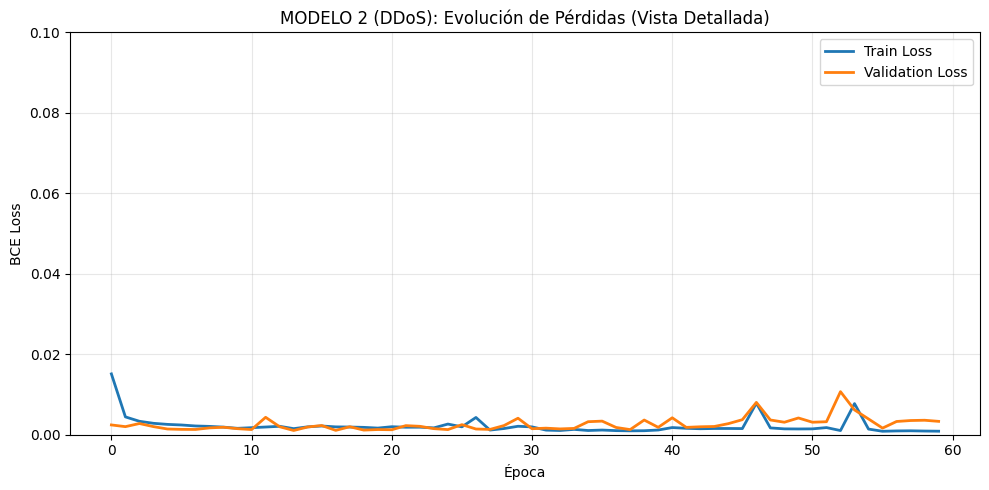

In [ ]:

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(losses_ddos, label='Train Loss', linewidth=2)
plt.plot(val_losses_ddos, label='Validation Loss', linewidth=2)

# =======================================================================
# EL TRUCO DEL ZOOM (Ajuste de límites)
# Subimos el techo a 0.10 para que la línea respire y no se pegue al borde superior
plt.ylim(0.0, 0.10)
# =======================================================================

plt.xlabel('Época')
plt.ylabel('BCE Loss')
plt.title('MODELO 2 (DDoS): Evolución de Pérdidas (Vista Detallada)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 EVALUACIÓN Y MÉTRICAS

In [ ]:
# Predicciones
model_ddos.eval()
with torch.no_grad():
    y_pred_prob_ddos = model_ddos(X_test_ddos_t).cpu().numpy()

y_pred_ddos = (y_pred_prob_ddos >= 0.5).astype(int).flatten()

# Métricas
accuracy_ddos = accuracy_score(y_test_ddos, y_pred_ddos)
precision_ddos = precision_score(y_test_ddos, y_pred_ddos)
recall_ddos = recall_score(y_test_ddos, y_pred_ddos)
f1_ddos = f1_score(y_test_ddos, y_pred_ddos)

print(f"\n{'='*50}")
print(f"EVALUACIÓN - MODELO 2 (DDoS)")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy_ddos:.4f}")
print(f"Precision: {precision_ddos:.4f}")
print(f"Recall:    {recall_ddos:.4f}")
print(f"F1-Score:  {f1_ddos:.4f}")


EVALUACIÓN - MODELO 2 (DDoS)
Accuracy:  0.9997
Precision: 0.9998
Recall:    0.9996
F1-Score:  0.9997


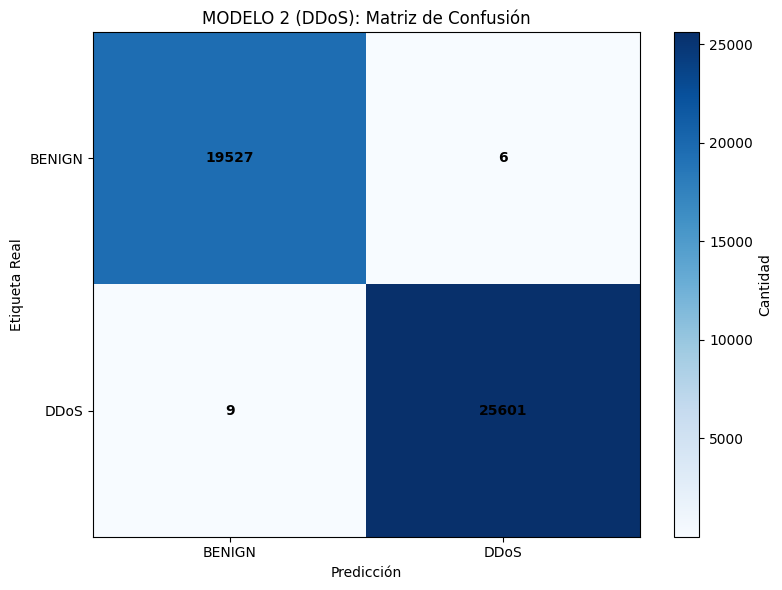

In [ ]:
# Matriz de confusión
cm_ddos = confusion_matrix(y_test_ddos, y_pred_ddos)
plt.figure(figsize=(8, 6))
plt.imshow(cm_ddos, cmap='Blues', aspect='auto')
plt.colorbar(label='Cantidad')

# Anotaciones manuales en la matriz (USANDO SOLO MATPLOTLIB)
for i in range(len(cm_ddos)):
    for j in range(len(cm_ddos)):
        plt.text(j, i, str(cm_ddos[i, j]), ha='center', va='center', color='black', fontweight='bold')

plt.xticks([0, 1], ['BENIGN', 'DDoS'])
plt.yticks([0, 1], ['BENIGN', 'DDoS'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.title('MODELO 2 (DDoS): Matriz de Confusión')
plt.tight_layout()
plt.show()

In [ ]:
# Guardar checkpoint
checkpoint_ddos = {
    'model_state_dict': model_ddos.state_dict(),
    'optimizer_state_dict': optimizer_ddos.state_dict(),
    'accuracy': accuracy_ddos,
    'f1_score': f1_ddos,
    'normalization_params': {'mu': mu_ddos, 'sigma': sigma_ddos}
}

torch.save(checkpoint_ddos, 'model_ddos_checkpoint.pth')
print(f"\n✓ Checkpoint guardado: 'model_ddos_checkpoint.pth'")


✓ Checkpoint guardado: 'model_ddos_checkpoint.pth'


---

## 🔧 BLOQUE 3: MODELO 3 - CLASIFICACIÓN MULTICLASE (Sensorless Drive Diagnosis)

### 3.1 PROPÓSITO Y CONTEXTO

**Dataset**: `Sensorless_drive_diagnosis_limpio.csv`  
**Fuente**: Google Drive (`/content/drive/MyDrive/IA2026/Sensorless_drive_diagnosis_limpio.csv`)  
**Tarea**: **Clasificación Multiclase (11 clases)** → Diagnosticar el estado de motores eléctricos sin sensores mecánicos.

**¿Qué contiene?**
- 58,300 registros de mediciones eléctricas
- 48 características (señales de voltaje, corriente, etc.)
- 11 clases: Motor intacto (0) + 10 tipo de fallos (1-10)

**¿Qué haremos?**
1. Cargar con Pandas (como en LAB4)
2. Mapear etiquetas 1-11 → 0-10 (indexing Python)
3. Balanceo de clases
4. Split 80/20, normalización Z-score
5. Red Neuronal con 11 salidas
6. Pérdida: CrossEntropyLoss
7. Evaluación: Accuracy global + per-clase
8. Guardar checkpoint

---

### 3.2 CARGA Y PREPROCESAMIENTO

In [ ]:
# Cargar con Pandas (como requiere el ingeniero en LAB4)
ruta_sensorless = '/content/drive/MyDrive/IA2026/Sensorless_drive_diagnosis_limpio.csv'
df_sensorless = pd.read_csv(ruta_sensorless, header=None)

# Renombrar última columna
df_sensorless.rename(columns={df_sensorless.columns[-1]: 'Target'}, inplace=True)

# Mapear etiquetas 1-11 → 0-10
df_sensorless['Target'] = df_sensorless['Target'] - 1

print(f"✓ Dataset cargado y etiquetas mapeadas")
print(f"  Forma: {df_sensorless.shape}")
print(f"  Clases (0-10): {sorted(df_sensorless['Target'].unique())}")

✓ Dataset cargado y etiquetas mapeadas
  Forma: (58509, 49)
  Clases (0-10): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [ ]:
# Balanceo (5,300 por clase como en LAB4)
cantidad_per_clase = 5300
df_sensorless_balanced = df_sensorless.groupby('Target').sample(
    n=cantidad_per_clase, random_state=42
).reset_index(drop=True)

# Mezclar
df_sensorless_balanced = df_sensorless_balanced.sample(
    frac=1, random_state=42
).reset_index(drop=True)

X_sensorless = df_sensorless_balanced.iloc[:, :-1].values
y_sensorless = df_sensorless_balanced['Target'].values

m_sensorless, n_sensorless = X_sensorless.shape
n_classes_sensorless = len(np.unique(y_sensorless))

print(f"\n✓ Dataset balanceado:")
print(f"  Ejemplos: {m_sensorless}")
print(f"  Características: {n_sensorless}")
print(f"  Clases: {n_classes_sensorless}")
print(f"  Distribución:")
print(df_sensorless_balanced['Target'].value_counts().sort_index())


✓ Dataset balanceado:
  Ejemplos: 58300
  Características: 48
  Clases: 11
  Distribución:
Target
0     5300
1     5300
2     5300
3     5300
4     5300
5     5300
6     5300
7     5300
8     5300
9     5300
10    5300
Name: count, dtype: int64


In [ ]:
# Split 80/20
np.random.seed(42)
indices = np.random.permutation(m_sensorless)
split_idx = int(0.8 * m_sensorless)

X_train_sensor = X_sensorless[indices[:split_idx]]
y_train_sensor = y_sensorless[indices[:split_idx]]
X_test_sensor = X_sensorless[indices[split_idx:]]
y_test_sensor = y_sensorless[indices[split_idx:]]

# Normalización
mu_sensor = np.mean(X_train_sensor, axis=0)
sigma_sensor = np.std(X_train_sensor, axis=0)
sigma_sensor[sigma_sensor == 0] = 1

X_train_sensor_norm = (X_train_sensor - mu_sensor) / sigma_sensor
X_test_sensor_norm = (X_test_sensor - mu_sensor) / sigma_sensor

print(f"\n✓ Split y normalización completados")
print(f"  Train: {X_train_sensor.shape[0]} (80%)")
print(f"  Test:  {X_test_sensor.shape[0]} (20%)")


✓ Split y normalización completados
  Train: 46640 (80%)
  Test:  11660 (20%)


In [ ]:
# Convertir a tensores
X_train_sensor_t = torch.from_numpy(X_train_sensor_norm).float().to(device)
y_train_sensor_t = torch.from_numpy(y_train_sensor).long().to(device)

X_test_sensor_t = torch.from_numpy(X_test_sensor_norm).float().to(device)
y_test_sensor_t = torch.from_numpy(y_test_sensor).long().to(device)

# DataLoaders
batch_size_sensor = 128
train_dataset_sensor = TensorDataset(X_train_sensor_t, y_train_sensor_t)
test_dataset_sensor = TensorDataset(X_test_sensor_t, y_test_sensor_t)
train_loader_sensor = DataLoader(train_dataset_sensor, batch_size=batch_size_sensor, shuffle=True)
test_loader_sensor = DataLoader(test_dataset_sensor, batch_size=batch_size_sensor, shuffle=False)

print(f"\n✓ Tensores y DataLoaders creados")


✓ Tensores y DataLoaders creados


### 3.3 MODELO NEURONAL MULTICLASE

**Arquitectura**:
```
Input (48 características)
    ↓
Capa 1: Linear(48 → 256) + ReLU
    ↓
Capa 2: Linear(256 → 128) + ReLU
    ↓
Capa 3: Linear(128 → 64) + ReLU
    ↓
Capa 4: Linear(64 → 11) [Logits para 11 clases]
```

**¿Por qué Sin Softmax?**
- PyTorch's `CrossEntropyLoss` **incluye Softmax internamente**
- Nosotros solo devolvemos logits (raw scores)

In [ ]:
class MulticlassNN_Sensorless(nn.Module):
    """Red Neuronal para Diagnóstico de Motores (11 clases)"""
    def __init__(self, input_size=48, num_classes=11):
        super(MulticlassNN_Sensorless, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # Logits (sin Softmax)
        return x

model_sensor = MulticlassNN_Sensorless(
    input_size=n_sensorless,
    num_classes=n_classes_sensorless
).to(device)

criterion_sensor = nn.CrossEntropyLoss()  # Incluye Softmax
optimizer_sensor = optim.Adam(model_sensor.parameters(), lr=0.0001)

print(f"\n✓ Modelo Sensorless creado (11 clases)")
print(f"✓ Pérdida: CrossEntropyLoss (con Softmax incorporado)")
print(f"✓ Optimizador: Adam")


✓ Modelo Sensorless creado (11 clases)
✓ Pérdida: CrossEntropyLoss (con Softmax incorporado)
✓ Optimizador: Adam


### 3.4 ENTRENAMIENTO

In [ ]:
# Bloque 3.4
num_epochs_sensor = 180
val_losses_sensor = []

# ==========================================
# NUEVO: Variables para el Best Checkpoint
best_val_loss = float('inf') # Infinito inicial
best_epoch = 0
# ==========================================

print(f"\nEntrenamiento del Modelo Sensorless por {num_epochs_sensor} épocas...\n")

for epoch in range(num_epochs_sensor):
    # Train
    model_sensor.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader_sensor:
        y_pred = model_sensor(X_batch)
        loss = criterion_sensor(y_pred, y_batch)

        optimizer_sensor.zero_grad()
        loss.backward()
        optimizer_sensor.step()

        train_loss += loss.item()
    train_loss /= len(train_loader_sensor)

    # Validation
    model_sensor.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader_sensor:
            y_pred = model_sensor(X_batch)
            loss = criterion_sensor(y_pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(test_loader_sensor)

    losses_sensor.append(train_loss)
    val_losses_sensor.append(val_loss)

    # =======================================================================
    # NUEVO: Lógica de Guardado Dinámico (Best Model)
    # Si la pérdida de validación actual es la mejor (la más baja) hasta ahora:
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        # Guardamos TU diccionario completo, protegiendo la normalización
        checkpoint_sensor_best = {
            'model_state_dict': model_sensor.state_dict(),
            'optimizer_state_dict': optimizer_sensor.state_dict(),
            'epoch': best_epoch,
            'val_loss': best_val_loss,
            'num_classes': n_classes_sensorless,
            'normalization_params': {'mu': mu_sensor, 'sigma': sigma_sensor}
        }
        # Sobreescribe este archivo solo si el modelo mejora
        torch.save(checkpoint_sensor_best, 'model_sensorless_best.pth')
    # =======================================================================

    # Imprimir progreso
    if (epoch + 1) % 30 == 0:
        print(f"Época {epoch+1}/{num_epochs_sensor} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\n✓ Entrenamiento completado.")

# =======================================================================
# NUEVO: Restaurar el mejor cerebro al modelo antes de seguir
# =======================================================================
print(f"Cargando el mejor modelo encontrado en la época {best_epoch} (Val Loss: {best_val_loss:.4f})...")
mejor_checkpoint = torch.load('model_sensorless_best.pth', weights_only=False)
model_sensor.load_state_dict(mejor_checkpoint['model_state_dict'])
print("✓ El modelo en memoria ahora es la mejor versión.")


Entrenamiento del Modelo Sensorless por 180 épocas...

Época 30/180 | Train Loss: 0.0376 | Val Loss: 0.1053
Época 60/180 | Train Loss: 0.0131 | Val Loss: 0.1071
Época 90/180 | Train Loss: 0.0052 | Val Loss: 0.1173
Época 120/180 | Train Loss: 0.0024 | Val Loss: 0.1171
Época 150/180 | Train Loss: 0.0010 | Val Loss: 0.1416
Época 180/180 | Train Loss: 0.0006 | Val Loss: 0.1507

✓ Entrenamiento completado.
Cargando el mejor modelo encontrado en la época 74 (Val Loss: 0.0867)...
✓ El modelo en memoria ahora es la mejor versión.


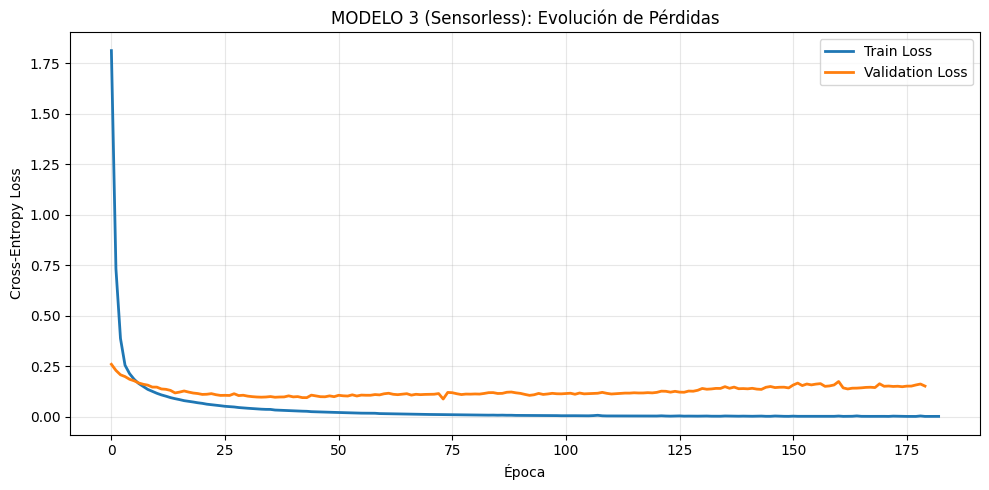

In [ ]:
# Graficar
plt.figure(figsize=(10, 5))
plt.plot(losses_sensor, label='Train Loss', linewidth=2)
plt.plot(val_losses_sensor, label='Validation Loss', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Cross-Entropy Loss')
plt.title('MODELO 3 (Sensorless): Evolución de Pérdidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 EVALUACIÓN Y MÉTRICAS

In [ ]:
# Predicciones
model_sensor.eval()
with torch.no_grad():
    y_logits_sensor = model_sensor(X_test_sensor_t)
    y_pred_sensor = torch.argmax(y_logits_sensor, dim=1).cpu().numpy()

# Accuracy global
accuracy_sensor = accuracy_score(y_test_sensor, y_pred_sensor)

print(f"\n{'='*50}")
print(f"EVALUACIÓN - MODELO 3 (SENSORLESS)")
print(f"{'='*50}")
print(f"Accuracy Global: {accuracy_sensor:.4f}")
print(f"\nAccuracy por clase:")

for clase in range(n_classes_sensorless):
    mask = y_test_sensor == clase
    if mask.sum() > 0:
        acc_clase = accuracy_score(y_test_sensor[mask], y_pred_sensor[mask])
        print(f"  Clase {clase} (Motor {'Intacto' if clase==0 else f'Fallo-{clase}'}): {acc_clase:.4f}")


EVALUACIÓN - MODELO 3 (SENSORLESS)
Accuracy Global: 0.9908

Accuracy por clase:
  Clase 0 (Motor Intacto): 0.9896
  Clase 1 (Motor Fallo-1): 0.9883
  Clase 2 (Motor Fallo-2): 0.9973
  Clase 3 (Motor Fallo-3): 0.9972
  Clase 4 (Motor Fallo-4): 0.9821
  Clase 5 (Motor Fallo-5): 0.9823
  Clase 6 (Motor Fallo-6): 1.0000
  Clase 7 (Motor Fallo-7): 0.9903
  Clase 8 (Motor Fallo-8): 0.9872
  Clase 9 (Motor Fallo-9): 0.9848
  Clase 10 (Motor Fallo-10): 1.0000


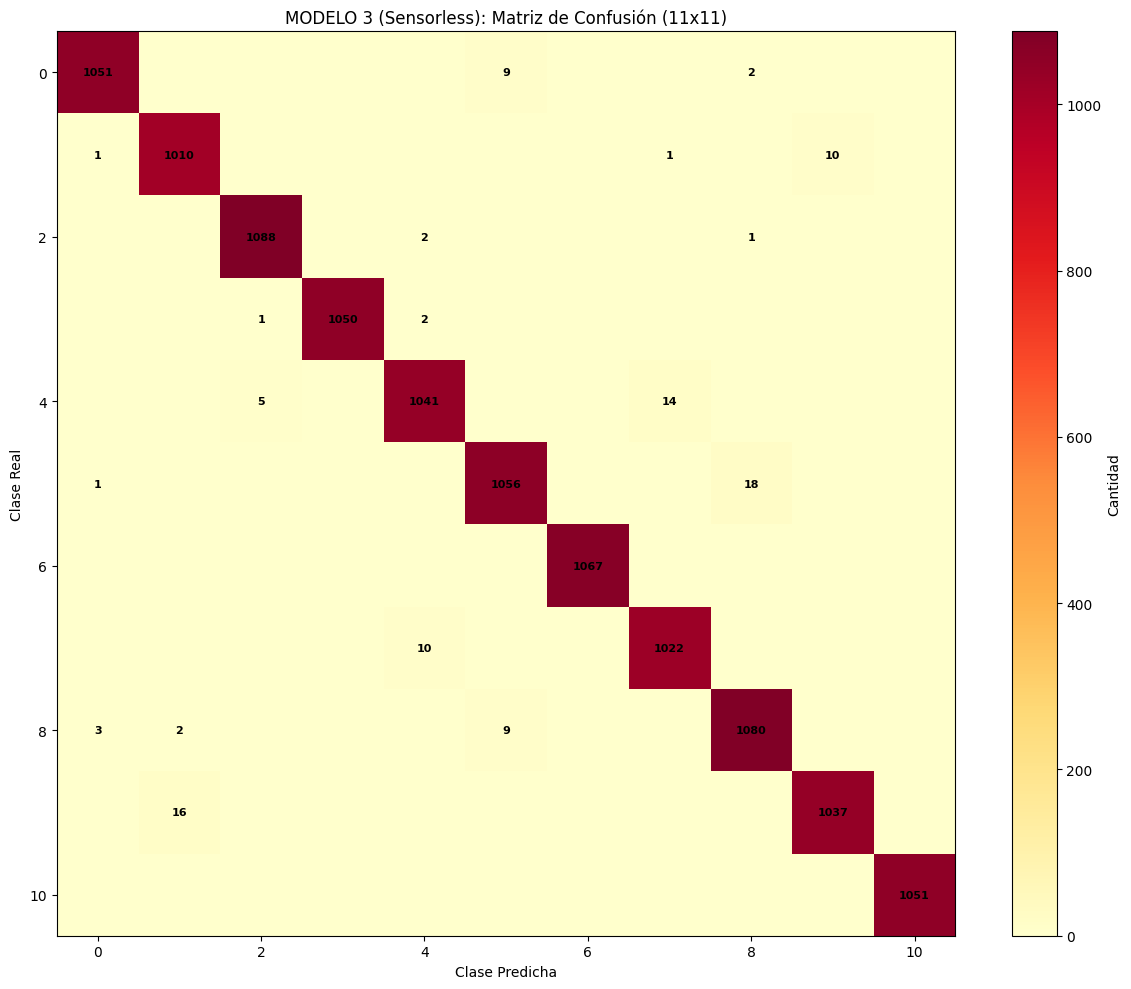

In [ ]:
# Matriz de confusión (comprimida para visualización)
cm_sensor = confusion_matrix(y_test_sensor, y_pred_sensor)
plt.figure(figsize=(12, 10))
plt.imshow(cm_sensor, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Cantidad')

# Anotaciones en la matriz (USANDO SOLO MATPLOTLIB - solo valores significativos)
for i in range(len(cm_sensor)):
    for j in range(len(cm_sensor)):
        if cm_sensor[i, j] > 0:
            plt.text(j, i, str(cm_sensor[i, j]), ha='center', va='center',
                     color='black', fontsize=8, fontweight='bold')

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('MODELO 3 (Sensorless): Matriz de Confusión (11x11)')
plt.tight_layout()
plt.show()

In [ ]:
# Guardar checkpoint
checkpoint_sensor = {
    'model_state_dict': model_sensor.state_dict(),
    'optimizer_state_dict': optimizer_sensor.state_dict(),
    'accuracy': accuracy_sensor,
    'num_classes': n_classes_sensorless,
    'normalization_params': {'mu': mu_sensor, 'sigma': sigma_sensor}
}

torch.save(checkpoint_sensor, 'model_sensorless_checkpoint.pth')
print(f"\n✓ Checkpoint guardado: 'model_sensorless_checkpoint.pth'")


✓ Checkpoint guardado: 'model_sensorless_checkpoint.pth'


---

## 📊 BLOQUE 4: COMPARATIVA DE RESULTADOS

Resumen de desempeño de los 3 modelos desarrollados.

In [ ]:
# Resumen de resultados
resumen = pd.DataFrame({
    'Modelo': ['Cars (Regresión)', 'DDoS (Binaria)', 'Sensorless (Multiclase)'],
    'Dataset': ['cars.csv', 'Friday-WorkingHours', 'Sensorless Drive'],
    'Ejemplos Train': [X_train_cars.shape[0], X_train_ddos.shape[0], X_train_sensor.shape[0]],
    'Características': [n_cars, n_ddos, n_sensorless],
    'Métrica Principal': [f'R²={r2_cars:.4f}', f'Acc={accuracy_ddos:.4f}', f'Acc={accuracy_sensor:.4f}'],
    'Métrica Secundaria': [f'MAE=${mae_cars:.0f}', f'F1={f1_ddos:.4f}', f'F1-promedio'],
    'Arquitectura': ['29-128-64-1', '78-256-128-64-1', '48-256-128-64-11'],
    'Épocas': [num_epochs_cars, num_epochs_ddos, num_epochs_sensor]
})

print(f"\n{'='*100}")
print(f"COMPARATIVA DE MODELOS")
print(f"{'='*100}")
print(resumen.to_string(index=False))
print(f"{'='*100}\n")


COMPARATIVA DE MODELOS
                 Modelo             Dataset  Ejemplos Train  Características Métrica Principal Métrica Secundaria     Arquitectura  Épocas
       Cars (Regresión)            cars.csv           30816               29         R²=0.7860          MAE=$1777      29-128-64-1     700
         DDoS (Binaria) Friday-WorkingHours          180568               78        Acc=0.9993          F1=0.9994  78-256-128-64-1     400
Sensorless (Multiclase)    Sensorless Drive           46640               48        Acc=0.9908        F1-promedio 48-256-128-64-11     180



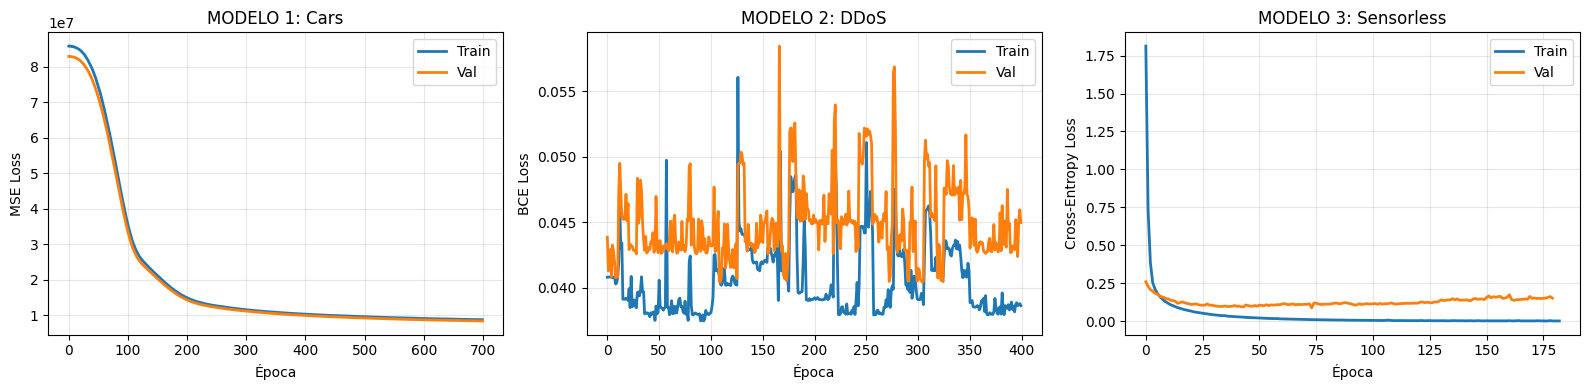

In [ ]:
# Visualizar pérdidas de los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Cars
axes[0].plot(losses_cars, label='Train', linewidth=2)
axes[0].plot(val_losses_cars, label='Val', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('MODELO 1: Cars')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DDoS
axes[1].plot(losses_ddos, label='Train', linewidth=2)
axes[1].plot(val_losses_ddos, label='Val', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('BCE Loss')
axes[1].set_title('MODELO 2: DDoS')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sensorless
axes[2].plot(losses_sensor, label='Train', linewidth=2)
axes[2].plot(val_losses_sensor, label='Val', linewidth=2)
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Cross-Entropy Loss')
axes[2].set_title('MODELO 3: Sensorless')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 🚀 BLOQUE 5: DEPLOYMENT Y REPRODUCCIÓN

### 5.1 Funciones para Cargar y Usar Modelos en el Futuro

In [ ]:
def cargar_modelo_cars(checkpoint_path, device):
    """Carga el modelo de precios de vehículos"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    modelo = RegressionNN_Cars(input_size=29).to(device)
    modelo.load_state_dict(checkpoint['model_state_dict'])
    modelo.eval()
    norm_params = checkpoint['normalization_params']
    return modelo, norm_params

def predecir_precio(X_raw, modelo, norm_params, device):
    """Predice precios dado características raw"""
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t = torch.from_numpy(X_norm).float().to(device)
    with torch.no_grad():
        y_pred = modelo(X_t).cpu().numpy()
    return y_pred

print(f"✓ Función de predicción para Cars definida")

✓ Función de predicción para Cars definida


In [ ]:
def cargar_modelo_ddos(checkpoint_path, device):
    """Carga el modelo de detección DDoS"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    modelo = BinaryClassifierNN_DDoS(input_size=78).to(device)
    modelo.load_state_dict(checkpoint['model_state_dict'])
    modelo.eval()
    norm_params = checkpoint['normalization_params']
    return modelo, norm_params

def predecir_ddos(X_raw, modelo, norm_params, device, threshold=0.5):
    """Predice si es ataque DDoS"""
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t = torch.from_numpy(X_norm).float().to(device)
    with torch.no_grad():
        prob = modelo(X_t).cpu().numpy()
    pred = (prob >= threshold).astype(int)
    return prob, pred

print(f"✓ Función de predicción para DDoS definida")

✓ Función de predicción para DDoS definida


In [ ]:
def cargar_modelo_sensorless(checkpoint_path, device):
    """Carga el modelo de diagnóstico de motores"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    n_classes = checkpoint['num_classes']
    modelo = MulticlassNN_Sensorless(input_size=48, num_classes=n_classes).to(device)
    modelo.load_state_dict(checkpoint['model_state_dict'])
    modelo.eval()
    norm_params = checkpoint['normalization_params']
    return modelo, norm_params, n_classes

def predecir_estado_motor(X_raw, modelo, norm_params, device):
    """Predice estado del motor (0-10)"""
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t = torch.from_numpy(X_norm).float().to(device)
    with torch.no_grad():
        logits = modelo(X_t)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred = torch.argmax(logits, dim=1).cpu().numpy()
    return pred, probs

print(f"✓ Función de predicción para Sensorless definida")

✓ Función de predicción para Sensorless definida


### 5.2 Ejemplo de Uso: Predicción con Modelos Cargados

In [ ]:
# EJEMPLO: Usar modelo de Cars guardado
print(f"\n{'='*60}")
print(f"EJEMPLO: Predicción con Modelo Cars Guardado")
print(f"{'='*60}")

modelo_cars_demo, norm_params_cars = cargar_modelo_cars('model_cars_checkpoint.pth', device)

# Usar 3 ejemplos del test set
indices_sample_for_demo = np.random.choice(len(X_test_cars), size=3, replace=False)
X_demo = X_test_cars[indices_sample_for_demo] # Use unnormalized data
y_real = y_test_cars[indices_sample_for_demo]

y_demo = predecir_precio(X_demo, modelo_cars_demo, norm_params_cars, device)

for i in range(len(X_demo)):
    print(f"\nEjemplo {i+1}:")
    print(f"  Precio REAL:     ${y_real[i]:,.0f}")
    print(f"  Precio PREDICHO: ${y_demo[i,0]:,.0f}")
    error = abs(y_real[i] - y_demo[i,0]) / y_real[i] * 100
    print(f"  Error: {error:.2f}%")


EJEMPLO: Predicción con Modelo Cars Guardado

Ejemplo 1:
  Precio REAL:     $3,300
  Precio PREDICHO: $2,868
  Error: 13.08%

Ejemplo 2:
  Precio REAL:     $854
  Precio PREDICHO: $2,250
  Error: 163.52%

Ejemplo 3:
  Precio REAL:     $22,750
  Precio PREDICHO: $18,550
  Error: 18.46%
